In [1]:
from sklearn.model_selection import train_test_split

from agent.components import RASK
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import pandas as pd
import plotly.io as pio

from notebooks.icsoc.globals import DATASET_LOG_SPLITS, \
    OVERALL_DATASET_USAGE, PATH_METRICS_PC_EXPLORE

plt.style.use('default')
pio.renderers.default = 'browser'

import numpy as np
import matplotlib.pyplot as plt

from agent.components.commons import ServiceType
from agent.components.commons import SloSet

In [2]:
largest_split = DATASET_LOG_SPLITS[-1]
_df_explore = pd.read_csv(PATH_METRICS_PC_EXPLORE)
_df_total = _df_explore.sample(frac=OVERALL_DATASET_USAGE, random_state=35)
train_df, _test_df_raw = train_test_split(_df_total, test_size=0.20, random_state=35)

test_df = RASK.preprocess_data(_test_df_raw)

services = [ServiceType.PC]
slos = [SloSet.DEFAULT, SloSet.HIGH_PERF, SloSet.LOW_COST, SloSet.HIGH_QUALITY]

<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
<>:59: SyntaxWarning: invalid escape sequence '\s'
<>:60: SyntaxWarning: invalid escape sequence '\s'
<>:64: SyntaxWarning: invalid escape sequence '\s'
C:\Users\boris\AppData\Local\Temp\ipykernel_9220\834434840.py:59: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(utilizations * 100, sim_results[ss], marker=markers[ss], linestyle='-', color=colors[ss], label=f'Simulation ($\sigma_s = {ss}$)')
C:\Users\boris\AppData\Local\Temp\ipykernel_9220\834434840.py:60: SyntaxWarning: invalid escape sequence '\s'
  plt.plot(utilizations * 100, kingman_results[ss], linestyle='--', color=dark_colors[ss], label=f"Kingman's Approx ($\sigma_s = {ss}$)")
C:\Users\boris\AppData\Local\Temp\ipykernel_9220\834434840.py:64: SyntaxWarning: invalid escape sequence '\s'
  plt.title("D/G/1 Queue: Deterministic Arrivals with Variable Service Times ($\sigm

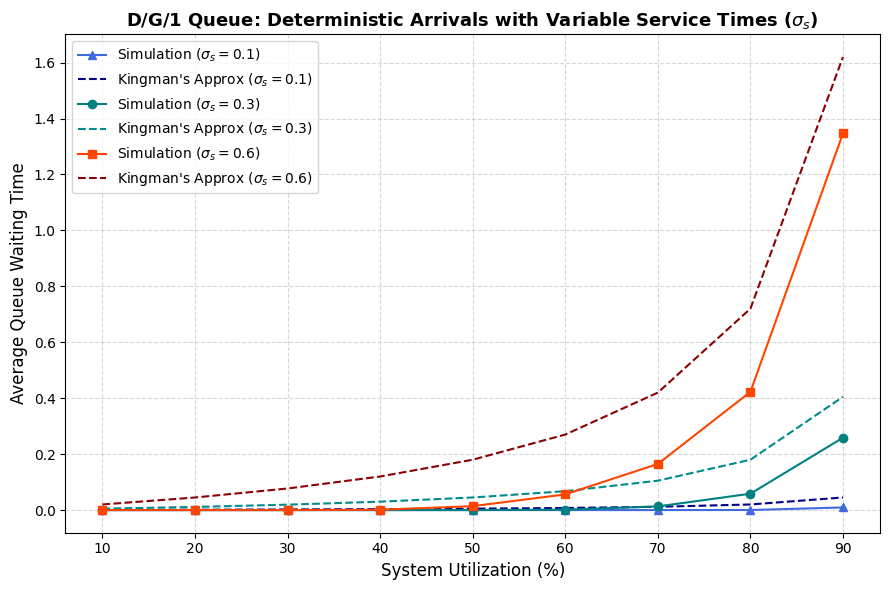

 Utilization  Sim (ss=0.1)  Kingman (ss=0.1)  Sim (ss=0.6)  Kingman (ss=0.6)  Sim (ss=1.0)  Kingman (ss=1.0)
         0.1  0.000000e+00          0.000556      0.000000          0.005000      0.000000          0.020000
         0.2  0.000000e+00          0.001250      0.000000          0.011250      0.000000          0.045000
         0.3  0.000000e+00          0.002143      0.000000          0.019286      0.000004          0.077143
         0.4  0.000000e+00          0.003333      0.000000          0.030000      0.001185          0.120000
         0.5  0.000000e+00          0.005000      0.000031          0.045000      0.013930          0.180000
         0.6  0.000000e+00          0.007500      0.001458          0.067500      0.056019          0.270000
         0.7  3.389002e-07          0.011667      0.013051          0.105000      0.164972          0.420000
         0.8  2.273049e-04          0.020000      0.058416          0.180000      0.422609          0.720000
         0.9  9.256

In [12]:
np.random.seed(42)

# Parameters
utilizations = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9])
sigmas_s = [0.1, 0.3, 0.6] # Service time standard deviations
mu_s = 1.0 # Mean service time

# Analytical Kingman for D/G/1 (Ca = 0)
# Wq = (rho / (1 - rho)) * (Cs^2 / 2) * mu_s
kingman_results = {}
for ss in sigmas_s:
    kingman_results[ss] = []
    Cs_sq = (ss / mu_s) ** 2
    for rho in utilizations:
        Wq_kingman = (rho / (1 - rho)) * (Cs_sq / 2) * mu_s
        kingman_results[ss].append(Wq_kingman)

# Simulation of D/G/1
def simulate_dg1(n_customers, mu_a, mu_s, sigma_s):
    # Deterministic inter-arrivals
    inter_arrivals = np.full(n_customers, mu_a)

    # Normally distributed service times (truncated at 1e-6 to avoid non-positive times)
    service_times = np.random.normal(mu_s, sigma_s, n_customers)
    service_times = np.clip(service_times, 1e-6, None)

    arrival_times = np.cumsum(inter_arrivals)

    start_service_times = np.zeros(n_customers)
    end_service_times = np.zeros(n_customers)
    waiting_times = np.zeros(n_customers)

    start_service_times[0] = arrival_times[0]
    end_service_times[0] = start_service_times[0] + service_times[0]

    for i in range(1, n_customers):
        start_service_times[i] = max(arrival_times[i], end_service_times[i-1])
        end_service_times[i] = start_service_times[i] + service_times[i]
        waiting_times[i] = start_service_times[i] - arrival_times[i]

    warmup = int(n_customers * 0.2)
    return np.mean(waiting_times[warmup:])

sim_results = {}
for ss in sigmas_s:
    sim_results[ss] = []
    for rho in utilizations:
        mu_a = mu_s / rho
        sim_results[ss].append(simulate_dg1(100000, mu_a, mu_s, ss))

# Plotting
plt.figure(figsize=(9, 6))

colors = {0.1: 'royalblue', 0.3: 'teal', 0.6: 'orangered'}
dark_colors = {0.1: 'darkblue', 0.3: 'darkcyan', 0.6: 'darkred'}
markers = {0.1: '^', 0.3: 'o', 0.6: 's'}

for ss in sigmas_s:
    plt.plot(utilizations * 100, sim_results[ss], marker=markers[ss], linestyle='-', color=colors[ss], label=f'Simulation ($\sigma_s = {ss}$)')
    plt.plot(utilizations * 100, kingman_results[ss], linestyle='--', color=dark_colors[ss], label=f"Kingman's Approx ($\sigma_s = {ss}$)")

plt.xlabel('System Utilization (%)', fontsize=12)
plt.ylabel('Average Queue Waiting Time', fontsize=12)
plt.title("D/G/1 Queue: Deterministic Arrivals with Variable Service Times ($\sigma_s$)", fontsize=13, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(frameon=True)
plt.tight_layout()
# plt.savefig('dg1_queue_comparison.png', dpi=300)
plt.show()

# Print specific table values
df_comp = pd.DataFrame({
    'Utilization': utilizations,
    'Sim (ss=0.1)': sim_results[0.1],
    'Kingman (ss=0.1)': kingman_results[0.1],
    'Sim (ss=0.6)': sim_results[0.3],
    'Kingman (ss=0.6)': kingman_results[0.3],
    'Sim (ss=1.0)': sim_results[0.6],
    'Kingman (ss=1.0)': kingman_results[0.6]
})
print(df_comp.to_string(index=False))